#Lab Tasks 03

##Lab Task 1: Loading and Visualising a Dataset

The purpose of this task is to load a dataset from Kaggle or the UCI Machine
Learning repository and visualise it.

Two datasets are used in this lab, both stored next to this notebook:

| File | Dataset | Used for |
|---|---|---|
| `penguins.csv` | Palmer Penguins — 344 penguins, 3 species, 4 body measurements | Tasks 1 and 2 |
| `breastcancer.csv` | Wisconsin Diagnostic Breast Cancer (UCI) — 569 samples, 30 features | Task 2, as a harder second dataset |

The Perceptron is a **binary** classifier, so a two-class problem is needed.
Following the same idea the manual uses for Iris — where the third class is
dropped so the remaining two are linearly separable — the penguins are reduced
to **Adelie** and **Gentoo**, and the Chinstrap rows are left out.

###1. Loading the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Colours used for the two classes throughout this notebook
CLASS_0_COLOR = "#2a78d6"   # blue
CLASS_1_COLOR = "#eb6834"   # orange
INK = "#0b0b0b"
INK_SOFT = "#52514e"
GRID = "#e6e5e0"

penguins = pd.read_csv("penguins.csv")

print("Shape:", penguins.shape)
print("\nSpecies counts:")
print(penguins["species"].value_counts())
print("\nMissing values per column:")
print(penguins.isna().sum())

penguins.head()

Shape: (344, 7)

Species counts:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Missing values per column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female


###2. Preparing a Two-Class Problem

Two of the four measurements are enough to tell Adelie and Gentoo apart, and
using exactly two features means the result can be drawn on a flat scatter plot
with the decision boundary on top.

The rows with missing measurements are dropped, and the species names are turned
into the numeric labels the Perceptron needs: **Adelie = 0**, **Gentoo = 1**.

In [2]:
feature_names = ["flipper_length_mm", "bill_depth_mm"]

# Keep only the two linearly separable species
two_species = penguins[penguins["species"].isin(["Adelie", "Gentoo"])]

# Drop the rows where either measurement is missing
two_species = two_species.dropna(subset=feature_names)

# Features and labels
X = two_species[feature_names].to_numpy(dtype="float64")
y = np.where(two_species["species"] == "Adelie", 0, 1)

print("Rows kept :", len(two_species))
print("X shape   :", X.shape, "| y shape:", y.shape)
print("Class 0 (Adelie):", (y == 0).sum(), "| Class 1 (Gentoo):", (y == 1).sum())

print("\nFeature ranges")
for i, name in enumerate(feature_names):
    print(f"  {name:<20}: {X[:, i].min():7.1f} to {X[:, i].max():7.1f}")

Rows kept : 274
X shape   : (274, 2) | y shape: (274,)
Class 0 (Adelie): 151 | Class 1 (Gentoo): 123

Feature ranges
  flipper_length_mm   :   172.0 to   231.0
  bill_depth_mm       :    13.1 to    21.5


###3. Visualising the Dataset

The two species separate cleanly: Gentoo penguins have longer flippers and
shallower bills than Adelie. A straight line can be drawn between the two
groups, which is exactly the condition the Perceptron needs in order to
converge.

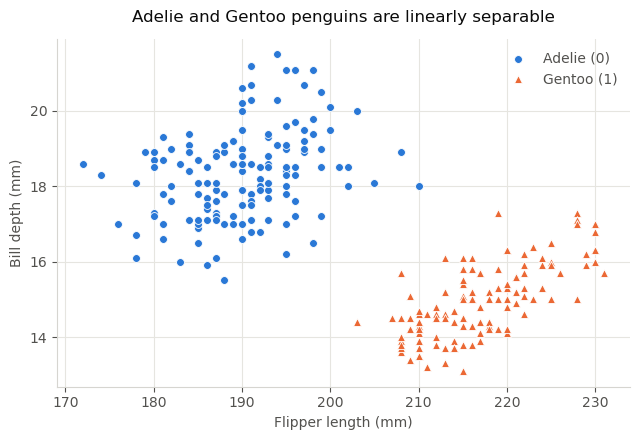

In [3]:
figure, axes = plt.subplots(figsize=(6.5, 4.5))

axes.scatter(X[y == 0, 0], X[y == 0, 1], marker="o", s=32,
             color=CLASS_0_COLOR, label="Adelie (0)",
             edgecolor="white", linewidth=0.6)
axes.scatter(X[y == 1, 0], X[y == 1, 1], marker="^", s=32,
             color=CLASS_1_COLOR, label="Gentoo (1)",
             edgecolor="white", linewidth=0.6)

axes.set_xlabel("Flipper length (mm)", color=INK_SOFT)
axes.set_ylabel("Bill depth (mm)", color=INK_SOFT)
axes.set_title("Adelie and Gentoo penguins are linearly separable",
               color=INK, fontsize=12, pad=12)
axes.legend(frameon=False, labelcolor=INK_SOFT)

axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.spines["left"].set_color("#d6d5d0")
axes.spines["bottom"].set_color("#d6d5d0")
axes.tick_params(colors=INK_SOFT)
axes.grid(True, color=GRID, linewidth=0.8)
axes.set_axisbelow(True)

plt.tight_layout()
plt.show()

##Lab Task 2: Implementing and Training the Perceptron

The purpose of this task is to implement the Perceptron, train it on the dataset
with the training algorithm, and show the learning curve and the weights.

**How a Perceptron works.** It has one node per input feature plus a bias, each
with a weight. The node takes the weighted sum of the inputs and passes it
through a **step function** that returns 1 if the sum is positive and 0
otherwise — so the output is a binary class label.

**The delta rule.** Training feeds the data through the network repeatedly. Each
full pass is one **epoch**. When a prediction is wrong, the weights step towards
the correct answer:

$$w(t+1) = w(t) + \alpha\,(d_j - y_j)\,x_j$$

* $(d_j - y_j)$ is 0 when the prediction is right, so correct predictions change
  nothing. When it is wrong, its sign gives the direction to move in.
* $\alpha$ is the **learning rate**, controlling how big each step is. Too large
  and the weights overshoot; too small and training takes too long.

**The bias trick.** A column of 1s is added to the input, so the bias becomes
just another trainable weight instead of a value tracked separately.

###1. The Perceptron Class

In [4]:
class Perceptron:
    def __init__(self, N, alpha=0.1):
        """N is the number of features, alpha is the learning rate."""
        # One weight per feature, plus one for the bias.
        # Dividing by sqrt(N) scales the weights and speeds up convergence.
        self.W = np.random.randn(N + 1) / np.sqrt(N)
        self.alpha = alpha
        self.errors_ = []   # misclassifications per epoch, for the learning curve

    def step(self, x):
        """Return 1 where x is positive and 0 elsewhere."""
        # np.where is used instead of `1 if x > 0 else 0` so that the same
        # function works for a single value and for a whole array at once.
        return np.where(x > 0, 1, 0)

    def fit(self, X, y, epochs=20):
        """Train the weights on X and y using the delta rule."""
        # The bias trick: append a column of 1s to the training data
        X = np.c_[X, np.ones((X.shape[0]))]
        self.errors_ = []

        for epoch in range(epochs):
            misclassified = 0

            for (x, target) in zip(X, y):
                # Take the dot product and pass it through the step function
                p = self.step(np.dot(x, self.W))

                # Only update the weights when the prediction is wrong
                if p != target:
                    misclassified += 1
                    error = p - target
                    self.W += -self.alpha * error * x

            self.errors_.append(misclassified)

        return self

    def predict(self, X, addBias=True):
        """Return the predicted class labels for X."""
        X = np.atleast_2d(X)
        if addBias:
            X = np.c_[X, np.ones((X.shape[0]))]
        return self.step(np.dot(X, self.W))


print("Perceptron class defined.")

Perceptron class defined.


###2. Scaling the Features

Flipper length runs to roughly 230 and bill depth to roughly 20, so the two
features are on very different scales. Every weight update is multiplied by the
feature value, which means the larger feature dominates the step and the
correction gets thrown a long way past the boundary.

Standardising each feature — subtracting its mean and dividing by its standard
deviation — puts both on the same footing. The effect is shown at the end of
this task.

In [5]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

print("Before scaling")
for i, name in enumerate(feature_names):
    print(f"  {name:<20}: mean {X[:, i].mean():7.2f} | std {X[:, i].std():6.2f}")

print("\nAfter scaling")
for i, name in enumerate(feature_names):
    print(f"  {name:<20}: mean {X_scaled[:, i].mean():7.2f} | std {X_scaled[:, i].std():6.2f}")

Before scaling
  flipper_length_mm   : mean  202.18 | std  15.02
  bill_depth_mm       : mean   16.84 | std   2.01

After scaling
  flipper_length_mm   : mean   -0.00 | std   1.00
  bill_depth_mm       : mean   -0.00 | std   1.00


###3. Training the Perceptron

The seed is fixed so that the random starting weights — and therefore every
number below — are the same each time the notebook is run.

In [6]:
np.random.seed(8)

model = Perceptron(N=X_scaled.shape[1], alpha=0.01)
model.fit(X_scaled, y, epochs=20)

predictions = model.predict(X_scaled)
accuracy = (predictions == y).mean()

print("Misclassified per epoch:", model.errors_)
print(f"\nTraining accuracy: {accuracy:.4f}  "
      f"({(predictions == y).sum()} of {len(y)} correct)")

Misclassified per epoch: [85, 6, 3, 2, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Training accuracy: 1.0000  (274 of 274 correct)


###4. The Learned Weights

In [7]:
# The last weight is the bias, because the bias trick appended its column last
weight_table = pd.DataFrame({
    "input": feature_names + ["bias"],
    "weight": model.W,
})
print(weight_table.to_string(index=False))

print("\nThe sign of each weight says which class it pushes towards:")
for name, weight in zip(feature_names, model.W[:-1]):
    direction = "Gentoo (1)" if weight > 0 else "Adelie (0)"
    print(f"  a larger {name:<20} pushes the output towards {direction}")

            input    weight
flipper_length_mm  0.796644
    bill_depth_mm -0.350327
             bias -0.466716

The sign of each weight says which class it pushes towards:
  a larger flipper_length_mm    pushes the output towards Gentoo (1)
  a larger bill_depth_mm        pushes the output towards Adelie (0)


###5. The Learning Curve

The curve starts high, drops sharply once the weights have moved into roughly
the right place, and reaches **zero misclassifications** — the dataset is
linearly separable, so the convergence property of the Perceptron holds. Once it
hits zero no prediction is wrong, no weight update happens, and the curve stays
flat for the remaining epochs.

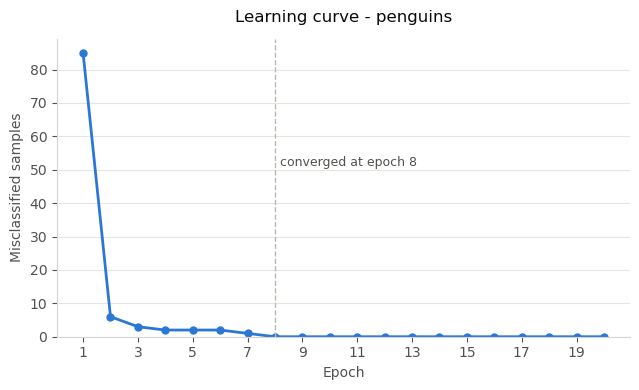

In [8]:
figure, axes = plt.subplots(figsize=(6.5, 4))

epochs = np.arange(1, len(model.errors_) + 1)
axes.plot(epochs, model.errors_, color=CLASS_0_COLOR, linewidth=2,
          marker="o", markersize=5)

# Mark the epoch where the Perceptron first classifies everything correctly
converged_at = next((e for e, err in zip(epochs, model.errors_) if err == 0), None)
if converged_at is not None:
    axes.axvline(converged_at, color="#b9b8b2", linewidth=1, linestyle="--")
    axes.text(converged_at + 0.2, max(model.errors_) * 0.6,
              f"converged at epoch {converged_at}", color=INK_SOFT, fontsize=9)

axes.set_xlabel("Epoch", color=INK_SOFT)
axes.set_ylabel("Misclassified samples", color=INK_SOFT)
axes.set_title("Learning curve - penguins", color=INK, fontsize=12, pad=12)
axes.set_xticks(epochs[::2])
axes.set_ylim(bottom=0)

axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.spines["left"].set_color("#d6d5d0")
axes.spines["bottom"].set_color("#d6d5d0")
axes.tick_params(colors=INK_SOFT)
axes.yaxis.grid(True, color=GRID, linewidth=0.8)
axes.set_axisbelow(True)

plt.tight_layout()
plt.show()

###6. The Decision Boundary

The weights are the line. The Perceptron predicts class 1 when

$$w_1x_1 + w_2x_2 + b > 0$$

so the boundary itself is where that sum equals zero, which rearranges to

$$x_2 = -\frac{w_1x_1 + b}{w_2}$$

Drawing that line over the scaled data shows what the weights actually
learned.

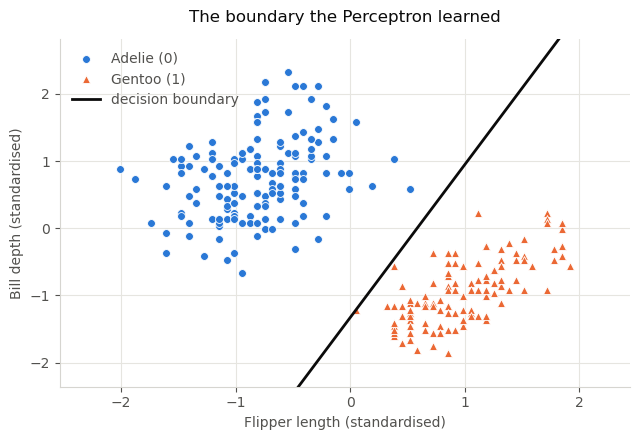

In [9]:
w1, w2, bias = model.W

# Two points are enough to draw a straight line
x1_line = np.array([X_scaled[:, 0].min() - 0.3, X_scaled[:, 0].max() + 0.3])
x2_line = -(w1 * x1_line + bias) / w2

figure, axes = plt.subplots(figsize=(6.5, 4.5))

axes.scatter(X_scaled[y == 0, 0], X_scaled[y == 0, 1], marker="o", s=32,
             color=CLASS_0_COLOR, label="Adelie (0)",
             edgecolor="white", linewidth=0.6)
axes.scatter(X_scaled[y == 1, 0], X_scaled[y == 1, 1], marker="^", s=32,
             color=CLASS_1_COLOR, label="Gentoo (1)",
             edgecolor="white", linewidth=0.6)
axes.plot(x1_line, x2_line, color=INK, linewidth=2, label="decision boundary")

axes.set_xlabel("Flipper length (standardised)", color=INK_SOFT)
axes.set_ylabel("Bill depth (standardised)", color=INK_SOFT)
axes.set_title("The boundary the Perceptron learned", color=INK, fontsize=12, pad=12)
axes.legend(frameon=False, labelcolor=INK_SOFT)
axes.set_ylim(X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5)

axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.spines["left"].set_color("#d6d5d0")
axes.spines["bottom"].set_color("#d6d5d0")
axes.tick_params(colors=INK_SOFT)
axes.grid(True, color=GRID, linewidth=0.8)
axes.set_axisbelow(True)

plt.tight_layout()
plt.show()

###7. What Happens Without Scaling

Training the same Perceptron on the raw, unscaled measurements shows why
section 2 was necessary. The error count per epoch looks low, but the final
accuracy is far worse than the scaled run — barely better than guessing.

The reason is the size of the update. Each correction is
`alpha * error * x`, and with a flipper length of about 200 a single late
correction moves the weights so far that the boundary lands somewhere useless.
The weights never settle; they just swing back and forth. This is the
overshooting behaviour the manual warns about when the step size is too
large — here caused by the size of the *inputs* rather than the learning rate
itself.

In [10]:
np.random.seed(8)

raw_model = Perceptron(N=X.shape[1], alpha=0.01)
raw_model.fit(X, y, epochs=20)
raw_accuracy = (raw_model.predict(X) == y).mean()

print("Unscaled - misclassified per epoch:", raw_model.errors_)
print(f"Unscaled - training accuracy: {raw_accuracy:.4f}")
print(f"Scaled   - training accuracy: {accuracy:.4f}")

Unscaled - misclassified per epoch: [2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 3]
Unscaled - training accuracy: 0.4489
Scaled   - training accuracy: 1.0000


###8. A Harder Dataset: Breast Cancer

The same Perceptron class is now applied to `breastcancer.csv`, without changing
a single line of it. This dataset is harder in two ways: it has **30 features**
instead of 2, and the two classes are **not perfectly linearly separable**.

The `id` column is dropped because it is an identifier and carries no
information, and so is the empty `Unnamed: 32` column that the file ends with.
The diagnosis is mapped to **B (benign) = 0** and **M (malignant) = 1**.

In [11]:
cancer = pd.read_csv("breastcancer.csv")

# Drop the identifier and the empty trailing column
cancer = cancer.drop(columns=["id", "Unnamed: 32"], errors="ignore")

cancer_features = cancer.drop(columns=["diagnosis"])
X_cancer = cancer_features.to_numpy(dtype="float64")
y_cancer = np.where(cancer["diagnosis"] == "M", 1, 0)

# Standardise, exactly as before - it matters even more with 30 features
X_cancer_scaled = (X_cancer - X_cancer.mean(axis=0)) / X_cancer.std(axis=0)

print("Shape:", X_cancer.shape)
print("Benign (0):", (y_cancer == 0).sum(), "| Malignant (1):", (y_cancer == 1).sum())

np.random.seed(1)
cancer_model = Perceptron(N=X_cancer_scaled.shape[1], alpha=0.001)
cancer_model.fit(X_cancer_scaled, y_cancer, epochs=30)

cancer_accuracy = (cancer_model.predict(X_cancer_scaled) == y_cancer).mean()
print(f"\nTraining accuracy: {cancer_accuracy:.4f}")
print("Misclassified per epoch:", cancer_model.errors_)

Shape: (569, 30)
Benign (0): 357 | Malignant (1): 212

Training accuracy: 0.9842
Misclassified per epoch: [97, 36, 25, 21, 18, 16, 17, 15, 13, 13, 11, 12, 9, 12, 11, 10, 9, 8, 8, 7, 9, 9, 8, 8, 9, 8, 8, 8, 9, 9]


###9. The Learning Curve on a Non-Separable Dataset

This curve behaves differently from the penguin one. It falls quickly at first
and then **flattens out above zero** instead of reaching it.

That is the Perceptron convergence property seen from the other side: the
guarantee only holds when the data is linearly separable. These two classes are
not, so a handful of samples stay on the wrong side of any straight line. Those
samples keep triggering weight updates forever, and the error count oscillates
instead of settling. It is the same limitation that stops a single Perceptron
from learning XOR.

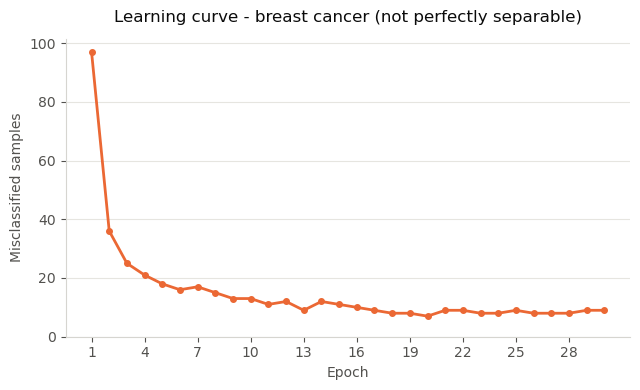

In [12]:
figure, axes = plt.subplots(figsize=(6.5, 4))

cancer_epochs = np.arange(1, len(cancer_model.errors_) + 1)
axes.plot(cancer_epochs, cancer_model.errors_, color=CLASS_1_COLOR,
          linewidth=2, marker="o", markersize=4)

axes.set_xlabel("Epoch", color=INK_SOFT)
axes.set_ylabel("Misclassified samples", color=INK_SOFT)
axes.set_title("Learning curve - breast cancer (not perfectly separable)",
               color=INK, fontsize=12, pad=12)
axes.set_xticks(cancer_epochs[::3])
axes.set_ylim(bottom=0)

axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.spines["left"].set_color("#d6d5d0")
axes.spines["bottom"].set_color("#d6d5d0")
axes.tick_params(colors=INK_SOFT)
axes.yaxis.grid(True, color=GRID, linewidth=0.8)
axes.set_axisbelow(True)

plt.tight_layout()
plt.show()

###10. The Weights on 30 Features

With 30 features there are 31 weights, so printing all of them is not very
readable. Sorting by size shows which measurements the Perceptron leaned on
most. A positive weight pushes the prediction towards *malignant*, a negative
one towards *benign*.

In [13]:
cancer_weights = pd.DataFrame({
    "feature": list(cancer_features.columns) + ["bias"],
    "weight": cancer_model.W,
})
cancer_weights["magnitude"] = cancer_weights["weight"].abs()
cancer_weights = cancer_weights.sort_values("magnitude", ascending=False)

print("Total weights:", len(cancer_weights), "(30 features + 1 bias)")
print("\n10 largest weights by magnitude:")
print(cancer_weights.head(10).to_string(index=False))

Total weights: 31 (30 features + 1 bias)

10 largest weights by magnitude:
         feature    weight  magnitude
     radius_mean  0.381513   0.381513
  concavity_mean  0.375481   0.375481
   texture_worst  0.329648   0.329648
       radius_se  0.315444   0.315444
compactness_mean -0.281514   0.281514
 perimeter_worst  0.248141   0.248141
      texture_se -0.222184   0.222184
 smoothness_mean  0.162028   0.162028
       area_mean -0.138308   0.138308
      area_worst  0.132343   0.132343


##Summary

| | Penguins | Breast cancer |
|---|---|---|
| Features | 2 | 30 |
| Samples | 274 | 569 |
| Linearly separable | Yes | No |
| Learning curve | Reaches 0 and stays there | Flattens out above 0 |
| Training accuracy | 1.0000 | 0.9842 |

Both runs used the same `Perceptron` class, the same delta rule and the same
bias trick. The difference in the two learning curves is a property of the
**data**, not of the code: the Perceptron is guaranteed to converge only when a
straight line can separate the classes.

#End!